# Data Cleaning and EDA


- Upload the data set before starting the process.

In [420]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [421]:
df = pd.read_csv("C:/Users/vssuj/OneDrive/Documents/EnergyFlow-PML_Project/Data/Raw_Electricity_Data.csv")
df.head()

,time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Precipitation,CloudCover,Temperature,Snowfall,Wind
0,2007-01-01 00:00:00,2.537017,0.092217,241.228917,10.486667,0.0,0.291667,0.000000,1.329846e-07,0.999695,286.43298,0.0,9.663516
1,2007-01-01 02:00:00,2.562000,0.098383,243.232917,10.470000,0.0,0.300000,0.000000,2.353721e-07,0.556274,285.98602,0.0,8.988889
2,2007-01-01 04:00:00,2.475983,0.094917,242.402417,10.130000,0.0,0.291667,0.000000,3.708734e-09,0.164459,284.50214,0.0,6.604268
3,2007-01-01 06:00:00,2.451500,0.096500,240.768000,10.111667,0.0,0.275000,0.000000,0.000000e+00,0.197144,283.30905,0.0,7.486063
4,2007-01-01 08:00:00,2.793933,0.072850,240.461000,11.550000,0.0,0.025000,6.016667,2.053049e-08,0.172791,282.31317,0.0,8.071110


In [422]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17295 entries, 0 to 17294
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   time                   17295 non-null  object 
 1   Global_active_power    16909 non-null  float64
 2   Global_reactive_power  16909 non-null  float64
 3   Voltage                16909 non-null  float64
 4   Global_intensity       16909 non-null  float64
 5   Sub_metering_1         16909 non-null  float64
 6   Sub_metering_2         16909 non-null  float64
 7   Sub_metering_3         16909 non-null  float64
 8   Precipitation          17295 non-null  float64
 9   CloudCover             17115 non-null  float64
 10  Temperature            17171 non-null  float64
 11  Snowfall               17295 non-null  float64
 12  Wind                   17295 non-null  float64
dtypes: float64(12), object(1)
memory usage: 1.7+ MB


In [423]:
df['time'] = pd.to_datetime(df['time'])

In [424]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17295 entries, 0 to 17294
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   time                   17295 non-null  datetime64[ns]
 1   Global_active_power    16909 non-null  float64       
 2   Global_reactive_power  16909 non-null  float64       
 3   Voltage                16909 non-null  float64       
 4   Global_intensity       16909 non-null  float64       
 5   Sub_metering_1         16909 non-null  float64       
 6   Sub_metering_2         16909 non-null  float64       
 7   Sub_metering_3         16909 non-null  float64       
 8   Precipitation          17295 non-null  float64       
 9   CloudCover             17115 non-null  float64       
 10  Temperature            17171 non-null  float64       
 11  Snowfall               17295 non-null  float64       
 12  Wind                   17295 non-null  float64       
dtypes

In [425]:
df.isna().sum()

time                       0
Global_active_power      386
Global_reactive_power    386
Voltage                  386
Global_intensity         386
Sub_metering_1           386
Sub_metering_2           386
Sub_metering_3           386
Precipitation              0
CloudCover               180
Temperature              124
Snowfall                   0
Wind                       0
dtype: int64

In [426]:
df[df['Global_active_power'].isna()]


,time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Precipitation,CloudCover,Temperature,Snowfall,Wind
1405,2007-04-28 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.006256,286.32025,0.000000e+00,1.878398
1406,2007-04-28 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.026245,285.62940,0.000000e+00,1.441969
1407,2007-04-28 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000,286.65405,0.000000e+00,2.334615
1408,2007-04-28 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000,291.37030,0.000000e+00,2.353884
1409,2007-04-28 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.649095e-10,0.000000,295.79346,0.000000e+00,1.818835
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17162,2010-11-30 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.353424,271.24725,3.311369e-11,4.663798
17171,2010-12-01 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.649095e-09,1.000000,270.71980,2.649095e-09,2.783768
17172,2010-12-01 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.934108e-09,1.000000,270.46063,9.900994e-09,1.467966
17173,2010-12-01 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.470248e-08,0.988739,270.29550,1.463625e-08,0.495738


In [427]:
s = df['Global_active_power'].isnull()

groups = (s != s.shift()).cumsum()

null_ranges = (
    df[s]
    .groupby(groups[s])
    .apply(lambda x: (x.index[0], x.index[-1], len(x)))
)

print(null_ranges)

Global_active_power
2       (1405, 1434, 30)
4     (10731, 10756, 26)
6      (11465, 11470, 6)
8     (13287, 13319, 33)
10    (13659, 13670, 12)
12    (13995, 14006, 12)
14    (14093, 14108, 16)
16    (14367, 14378, 12)
18    (14727, 14738, 12)
20    (15099, 15110, 12)
22    (15459, 15470, 12)
24    (15831, 15842, 12)
26    (15902, 15960, 59)
28    (16203, 16214, 12)
30    (16361, 16403, 43)
32    (16563, 16574, 12)
34    (16935, 16946, 12)
36    (17114, 17162, 49)
38     (17171, 17174, 4)
dtype: object


In [428]:
df.iloc[1400:1445] 
# to check the null value series range: - 30  

,time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Precipitation,CloudCover,Temperature,Snowfall,Wind
1400,2007-04-27 16:00:00,0.415533,0.122183,235.272417,1.808333,0.000000,0.491667,0.000000,0.000000e+00,0.000000,298.30896,0.0,2.032198
1401,2007-04-27 18:00:00,1.174017,0.202883,235.336917,5.190000,6.966667,0.483333,0.000000,0.000000e+00,0.000000,295.78400,0.0,0.497330
1402,2007-04-27 20:00:00,2.192933,0.125617,233.791333,9.420000,7.800000,0.441667,13.366667,0.000000e+00,0.007507,291.35950,0.0,0.395548
1403,2007-04-27 22:00:00,1.902583,0.101167,235.567500,8.096667,0.000000,0.325000,8.200000,0.000000e+00,0.003754,290.48737,0.0,0.179785
1404,2007-04-28 00:00:00,1.082762,0.136190,233.986190,4.638095,0.000000,0.857143,0.000000,0.000000e+00,0.000000,286.61023,0.0,0.871761
1405,2007-04-28 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.006256,286.32025,0.0,1.878398
1406,2007-04-28 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.026245,285.62940,0.0,1.441969
1407,2007-04-28 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000,286.65405,0.0,2.334615
1408,2007-04-28 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000,291.37030,0.0,2.353884
1409,2007-04-28 10:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.649095e-10,0.000000,295.79346,0.0,1.818835


In [429]:
df['Global_active_power'].nunique()

16586

In [430]:
df['Year'] = df['time'].dt.year

In [431]:
df['month'] = df["time"].dt.month

In [432]:
df["Date"] = df['time'].dt.date

In [433]:
df['Time'] = df['time'].dt.time
df['Time']

0        00:00:00
1        02:00:00
2        04:00:00
3        06:00:00
4        08:00:00
           ...   
17290    14:00:00
17291    16:00:00
17292    18:00:00
17293    20:00:00
17294    22:00:00
Name: Time, Length: 17295, dtype: object

In [434]:
df = df.set_index('time')

In [435]:
df.interpolate(method='time', inplace=True)

C:\Users\vssuj\AppData\Local\Temp\ipykernel_2744\997848166.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(method='time', inplace=True)


In [436]:
df.isna().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
Precipitation            0
CloudCover               0
Temperature              0
Snowfall                 0
Wind                     0
Year                     0
month                    0
Date                     0
Time                     0
dtype: int64

In [437]:
df.iloc[1405:1425]

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Precipitation,CloudCover,Temperature,Snowfall,Wind,Year,month,Date,Time
time,,,,,,,,,,,,,,,,
2007-04-28 02:00:00,1.065856,0.135032,234.007634,4.567041,0.0,0.849318,0.169019,0.000000e+00,0.006256,286.32025,0.0,1.878398,2007,4,2007-04-28,02:00:00
2007-04-28 04:00:00,1.048951,0.133873,234.029077,4.495987,0.0,0.841494,0.338038,0.000000e+00,0.026245,285.62940,0.0,1.441969,2007,4,2007-04-28,04:00:00
2007-04-28 06:00:00,1.032045,0.132714,234.050521,4.424933,0.0,0.833669,0.507056,0.000000e+00,0.000000,286.65405,0.0,2.334615,2007,4,2007-04-28,06:00:00
2007-04-28 08:00:00,1.015139,0.131556,234.071964,4.353879,0.0,0.825845,0.676075,0.000000e+00,0.000000,291.37030,0.0,2.353884,2007,4,2007-04-28,08:00:00
2007-04-28 10:00:00,0.998234,0.130397,234.093408,4.282825,0.0,0.818020,0.845094,2.649095e-10,0.000000,295.79346,0.0,1.818835,2007,4,2007-04-28,10:00:00
2007-04-28 12:00:00,0.981328,0.129238,234.114851,4.211770,0.0,0.810196,1.014113,1.589457e-09,0.000000,297.95392,0.0,1.610154,2007,4,2007-04-28,12:00:00
2007-04-28 14:00:00,0.964423,0.128080,234.136295,4.140716,0.0,0.802371,1.183132,3.708734e-09,0.145874,298.90510,0.0,0.757414,2007,4,2007-04-28,14:00:00
2007-04-28 16:00:00,0.947517,0.126921,234.157738,4.069662,0.0,0.794547,1.352151,4.900826e-09,0.000000,298.63095,0.0,0.893967,2007,4,2007-04-28,16:00:00
2007-04-28 18:00:00,0.930611,0.125762,234.179182,3.998608,0.0,0.786722,1.521169,1.153681e-07,0.023743,296.39350,0.0,0.763186,2007,4,2007-04-28,18:00:00


In [438]:
df.nunique()

Global_active_power      16972
Global_reactive_power    11081
Voltage                  16966
Global_intensity         14720
Sub_metering_1            1395
Sub_metering_2            1751
Sub_metering_3            2688
Precipitation             1521
CloudCover                7760
Temperature              17085
Snowfall                   336
Wind                     17282
Year                         4
month                       12
Date                      1441
Time                        12
dtype: int64

<Axes: xlabel='Year', ylabel='Global_active_power'>

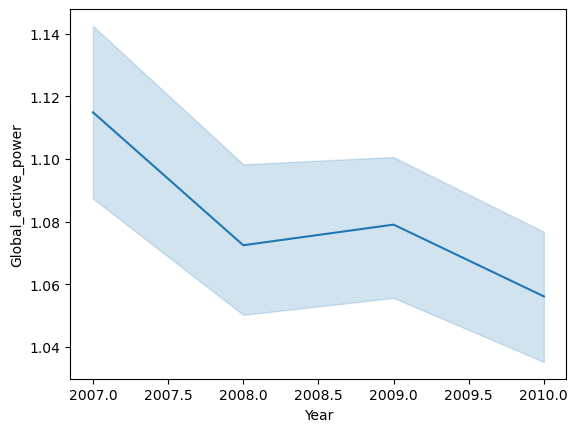

In [439]:
sns.lineplot(x = df['Year'], y = df['Global_active_power'])

<Axes: xlabel='month', ylabel='Global_active_power'>

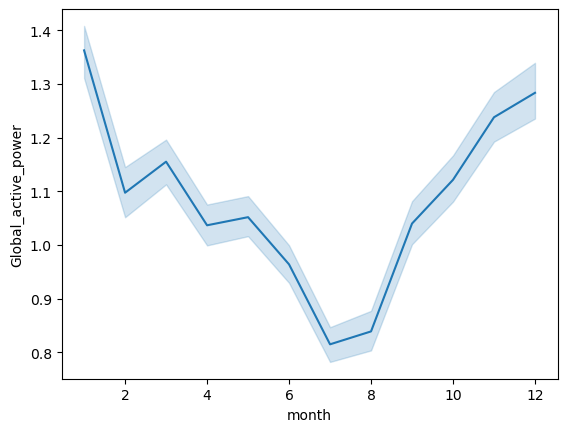

In [440]:
sns.lineplot(x = df["month"], y = df['Global_active_power'])

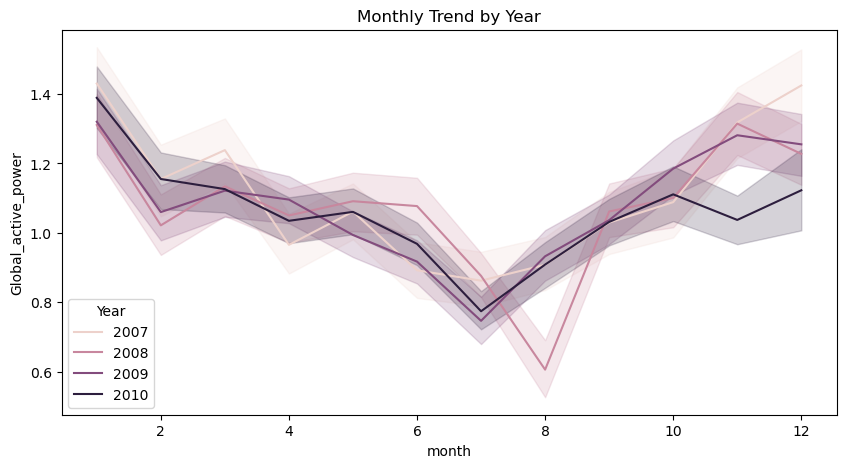

In [441]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x=df['month'],
    y=df['Global_active_power'],
    hue=df['Year']
)

plt.title("Monthly Trend by Year")
plt.show()

In [442]:
df

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Precipitation,CloudCover,Temperature,Snowfall,Wind,Year,month,Date,Time
time,,,,,,,,,,,,,,,,
2007-01-01 00:00:00,2.537017,0.092217,241.228917,10.486667,0.000,0.291667,0.000000,1.329846e-07,0.999695,286.43298,0.0,9.663516,2007,1,2007-01-01,00:00:00
2007-01-01 02:00:00,2.562000,0.098383,243.232917,10.470000,0.000,0.300000,0.000000,2.353721e-07,0.556274,285.98602,0.0,8.988889,2007,1,2007-01-01,02:00:00
2007-01-01 04:00:00,2.475983,0.094917,242.402417,10.130000,0.000,0.291667,0.000000,3.708734e-09,0.164459,284.50214,0.0,6.604268,2007,1,2007-01-01,04:00:00
2007-01-01 06:00:00,2.451500,0.096500,240.768000,10.111667,0.000,0.275000,0.000000,0.000000e+00,0.197144,283.30905,0.0,7.486063,2007,1,2007-01-01,06:00:00
2007-01-01 08:00:00,2.793933,0.072850,240.461000,11.550000,0.000,0.025000,6.016667,2.053049e-08,0.172791,282.31317,0.0,8.071110,2007,1,2007-01-01,08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-12-11 14:00:00,1.555850,0.168850,236.979333,6.818333,0.000,0.258333,10.625000,0.000000e+00,1.000000,278.62927,0.0,1.694674,2010,12,2010-12-11,14:00:00
2010-12-11 16:00:00,1.908883,0.191567,233.290500,8.260000,0.000,0.608333,5.958333,1.589457e-09,1.000000,278.68933,0.0,0.930473,2010,12,2010-12-11,16:00:00
2010-12-11 18:00:00,2.336417,0.105783,231.377417,10.098333,0.175,0.000000,6.566667,1.298057e-08,1.000000,278.19742,0.0,0.700579,2010,12,2010-12-11,18:00:00


In [462]:
daily_data = df.groupby(['month','Date'])['Global_active_power'].mean().reset_index()
daily_data

,month,Date,Global_active_power
0,1,2007-01-01,1.909031
1,1,2007-01-02,1.267194
2,1,2007-01-03,0.359419
3,1,2007-01-04,1.934689
4,1,2007-01-05,1.155457
...,...,...,...
1436,12,2010-12-07,0.770537
1437,12,2010-12-08,0.367846
1438,12,2010-12-09,1.119508
1439,12,2010-12-10,1.097008


In [477]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17295 entries, 2007-01-01 00:00:00 to 2010-12-11 22:00:00
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    17295 non-null  float64
 1   Global_reactive_power  17295 non-null  float64
 2   Voltage                17295 non-null  float64
 3   Global_intensity       17295 non-null  float64
 4   Sub_metering_1         17295 non-null  float64
 5   Sub_metering_2         17295 non-null  float64
 6   Sub_metering_3         17295 non-null  float64
 7   Precipitation          17295 non-null  float64
 8   CloudCover             17295 non-null  float64
 9   Temperature            17295 non-null  float64
 10  Snowfall               17295 non-null  float64
 11  Wind                   17295 non-null  float64
 12  Year                   17295 non-null  int32  
 13  month                  17295 non-null  int32  
 14  Date               

<Axes: >

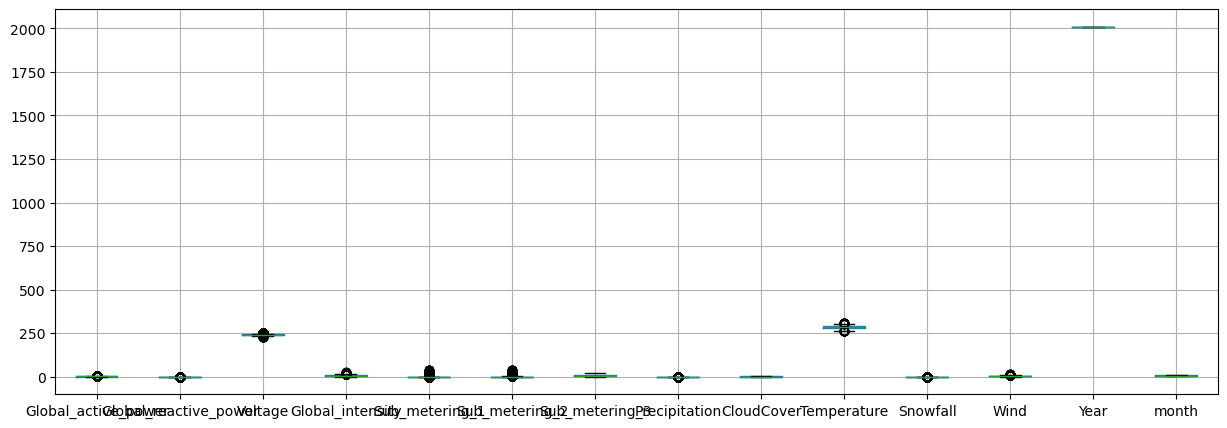

In [481]:
plt.figure(figsize=(15,5))
df.boxplot()

<Axes: >

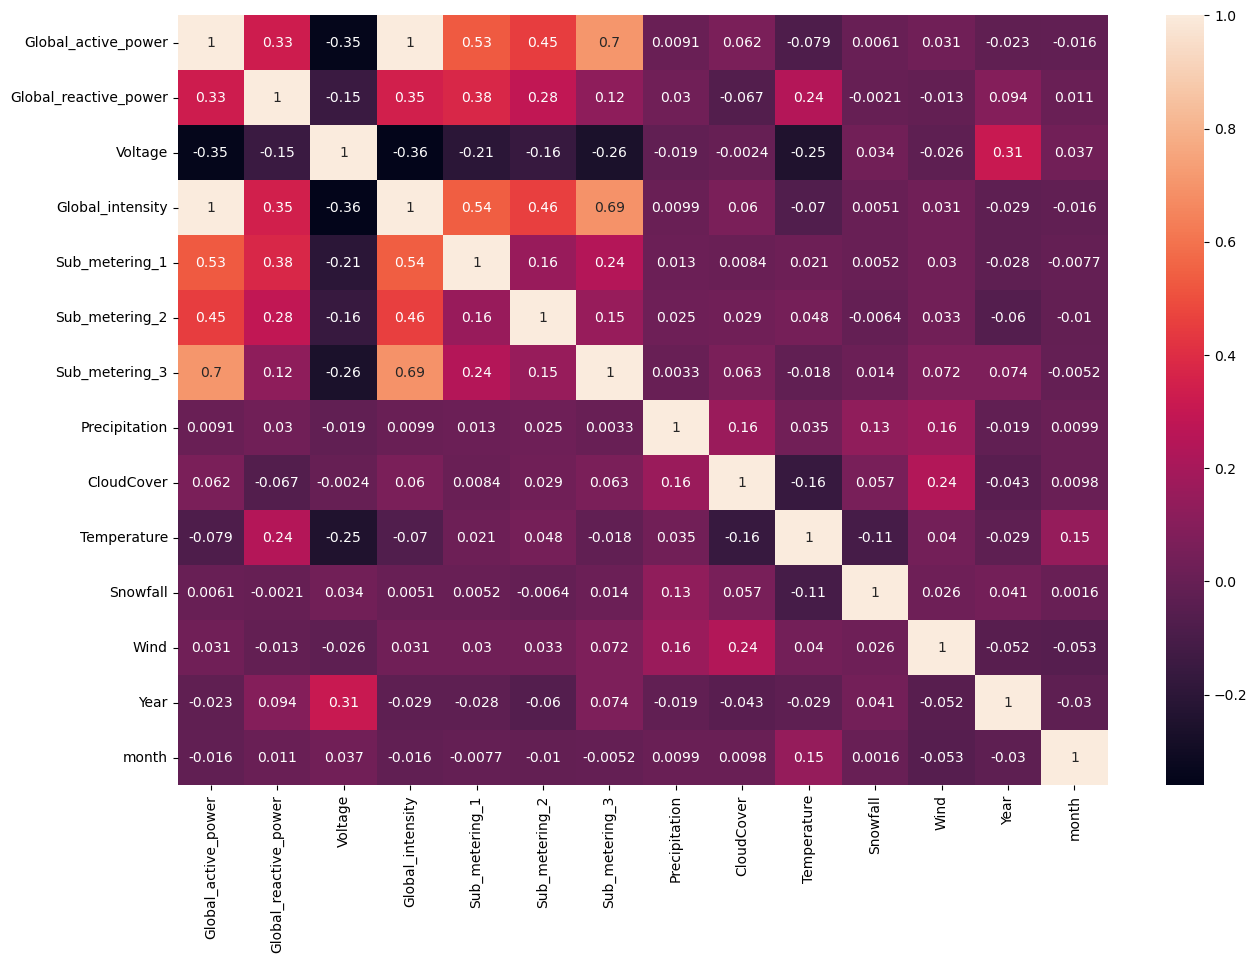

In [478]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)

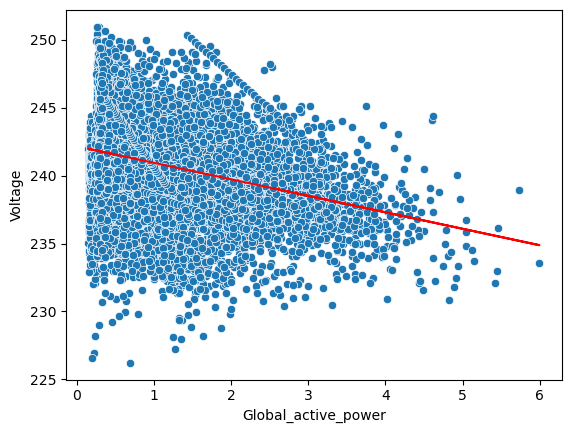

In [490]:
x = df['Global_active_power']
y = df['Voltage']
m, b = np.polyfit(x, y, 1)
sns.scatterplot(x=df["Global_active_power"], y=df["Voltage"])
plt.plot(x, m*x + b, color="red")

<Axes: xlabel='Global_active_power', ylabel='Count'>

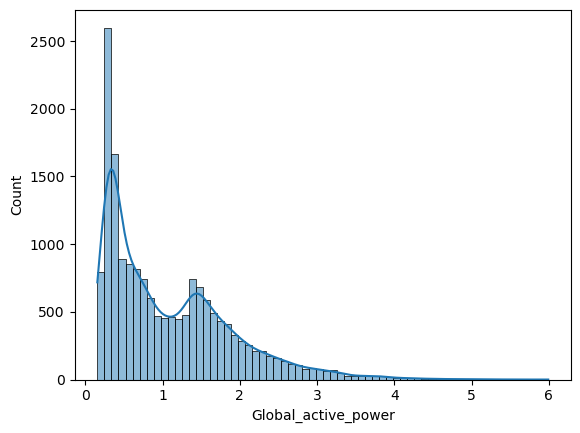

In [494]:
sns.histplot(df['Global_active_power'],kde=True)

In [501]:
new_df = df.drop('Global_intensity',axis=1)
new_df

,Global_active_power,Global_reactive_power,Voltage,Sub_metering_1,Sub_metering_2,Sub_metering_3,Precipitation,CloudCover,Temperature,Snowfall,Wind,Year,month,Date,Time
time,,,,,,,,,,,,,,,
2007-01-01 00:00:00,2.537017,0.092217,241.228917,0.000,0.291667,0.000000,1.329846e-07,0.999695,286.43298,0.0,9.663516,2007,1,2007-01-01,00:00:00
2007-01-01 02:00:00,2.562000,0.098383,243.232917,0.000,0.300000,0.000000,2.353721e-07,0.556274,285.98602,0.0,8.988889,2007,1,2007-01-01,02:00:00
2007-01-01 04:00:00,2.475983,0.094917,242.402417,0.000,0.291667,0.000000,3.708734e-09,0.164459,284.50214,0.0,6.604268,2007,1,2007-01-01,04:00:00
2007-01-01 06:00:00,2.451500,0.096500,240.768000,0.000,0.275000,0.000000,0.000000e+00,0.197144,283.30905,0.0,7.486063,2007,1,2007-01-01,06:00:00
2007-01-01 08:00:00,2.793933,0.072850,240.461000,0.000,0.025000,6.016667,2.053049e-08,0.172791,282.31317,0.0,8.071110,2007,1,2007-01-01,08:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-12-11 14:00:00,1.555850,0.168850,236.979333,0.000,0.258333,10.625000,0.000000e+00,1.000000,278.62927,0.0,1.694674,2010,12,2010-12-11,14:00:00
2010-12-11 16:00:00,1.908883,0.191567,233.290500,0.000,0.608333,5.958333,1.589457e-09,1.000000,278.68933,0.0,0.930473,2010,12,2010-12-11,16:00:00
2010-12-11 18:00:00,2.336417,0.105783,231.377417,0.175,0.000000,6.566667,1.298057e-08,1.000000,278.19742,0.0,0.700579,2010,12,2010-12-11,18:00:00


<Axes: >

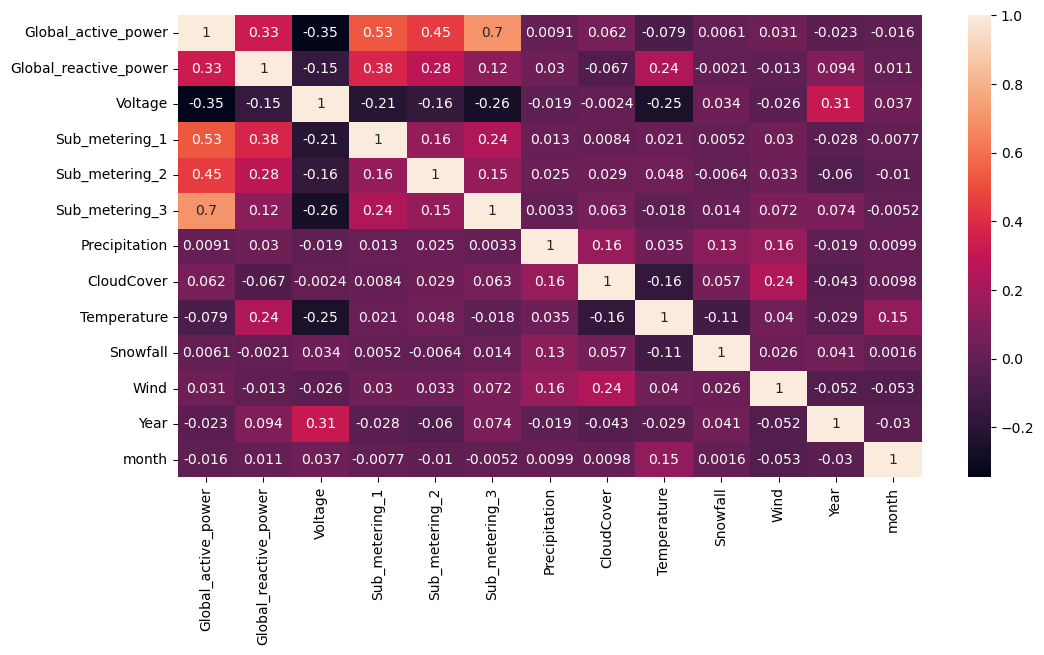

In [504]:
plt.figure(figsize=(12,6))
sns.heatmap(new_df.corr(numeric_only=True),annot=True)